### Integrantes:
- Valentina Giraldo Gaviria
- Sara Emanuelle Calderón

### **1. Carga de paquetes**

In [53]:
!pip install optuna
!pip install openpyxl


In [54]:
### 1. Carga de paquetes y configuración inicial

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Suavización exponencial
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

# Descomposición
from statsmodels.tsa.seasonal import seasonal_decompose

# Métricas
from sklearn.metrics import mean_squared_error

# Optuna
import optuna
import random
import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# SEMILLA PARA REPRODUCIBILIDAD
# ---------------------------------------------------------
np.random.seed(42)
random.seed(42)

# Semilla para Optuna (TPE sampler)
sampler = optuna.samplers.TPESampler(seed=42)
# ---------------------------------------------------------

plt.style.use("seaborn-v0_8")


### **2. Carga de datos**

In [55]:
data = pd.read_excel(r"datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


In [56]:
# imprimiendo el tamano del dataframe
print(data.shape)

(222, 4)


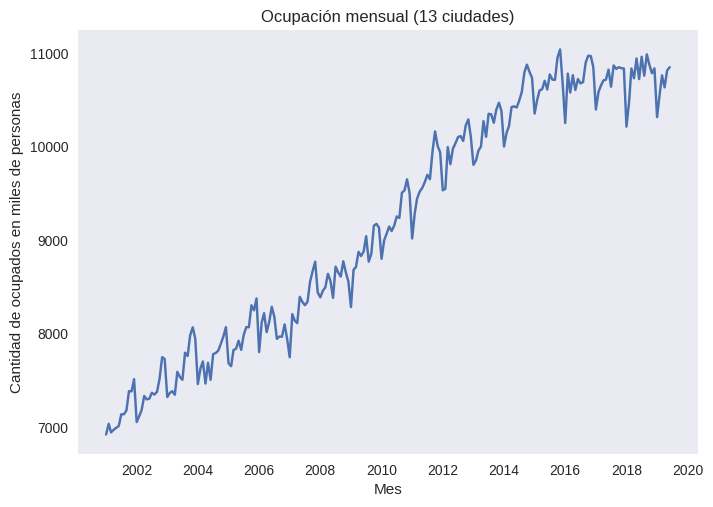

In [57]:
# Graficando los datos
plt.title("Ocupación mensual (13 ciudades)")
plt.xlabel("Mes")
plt.ylabel("Cantidad de ocupados en miles de personas")
plt.plot(data[["Ocupados"]])
plt.grid()
plt.show()

### **5. Optuna para Holt-Winters clásico**


## 5.1 **Dividir datos en entrenamiento y prueba**

### 5.2 **Función de evaluación rolling (ventana móvil)**

In [90]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error
import numpy as np

def evaluar_hw_expanding(y, params, window=12, step_size=1, horizon=6):

    alpha, beta, gamma, trend, seasonal, error, m = params

    n = len(y)
    predichos = []
    observados = []

    puntos_finales = range(n - window, n - horizon + 1, step_size)

    for end in puntos_finales:
        train = y[:end]
        test  = y[end:end+horizon]

        if len(test) < horizon:
            continue

        try:
            model = ETSModel(
                endog=train,
                trend=trend,
                seasonal=seasonal,
                error=error,
                seasonal_periods=m,
                freq="MS"
            )

            ajuste = model.fit_constrained({
                "smoothing_level": alpha,
                "smoothing_trend": beta,
                "smoothing_seasonal": gamma
            })

            pred = ajuste.forecast(horizon)

            predichos.extend(pred)
            observados.extend(test.values)

        except:
            continue

    if len(predichos)==0:
        return np.inf

    return np.sqrt(mean_squared_error(observados, predichos))


### 5.3* Función objetivo de Optuna para Holt-Winters*

In [91]:

def objective_hw(trial):

    alpha  = trial.suggest_float("alpha", 0.01, 1.0)
    beta   = trial.suggest_float("beta",  0.00, 1.0)
    gamma  = trial.suggest_float("gamma", 0.00, 1.0)

    trend    = trial.suggest_categorical("trend", ["add", "mul"])
    seasonal = trial.suggest_categorical("seasonal", ["add", "mul"])
    error    = trial.suggest_categorical("error", ["add", "mul"])

    # Restricción lógica ETS (muy importante)
    if seasonal == "mul" and error == "add":
        raise optuna.exceptions.TrialPruned()

    params = (alpha, beta, gamma, trend, seasonal, error, 12)

    y = train_td

    return evaluar_hw_expanding(y, params, window=12, step_size=1, horizon=6)


### 5.4 **Optimización bayesiana con Optuna**

In [92]:
study_hw = optuna.create_study(direction="minimize")
study_hw.optimize(objective_hw, n_trials=40)

print("Mejores hiperparámetros:")
print(study_hw.best_params)
print("RMSE mínimo:", study_hw.best_value)


[I 2025-11-16 21:36:10,830] A new study created in memory with name: no-name-9d285fdf-2cbb-4148-8f7f-1d23418b73f7
[I 2025-11-16 21:36:10,835] Trial 0 pruned. 
[I 2025-11-16 21:36:12,613] Trial 1 finished with value: 444.70154114470364 and parameters: {'alpha': 0.4191317062634795, 'beta': 0.4624853068495349, 'gamma': 0.8967151923752401, 'trend': 'add', 'seasonal': 'add', 'error': 'add'}. Best is trial 1 with value: 444.70154114470364.
[I 2025-11-16 21:36:16,172] Trial 2 finished with value: 324533.59109950025 and parameters: {'alpha': 0.9659050627261683, 'beta': 0.9977339503873078, 'gamma': 0.5749229424491193, 'trend': 'mul', 'seasonal': 'add', 'error': 'add'}. Best is trial 1 with value: 444.70154114470364.
[I 2025-11-16 21:36:17,610] Trial 3 finished with value: 690.8557288960833 and parameters: {'alpha': 0.9207039318017743, 'beta': 0.6604795493575697, 'gamma': 0.3312428375374463, 'trend': 'add', 'seasonal': 'add', 'error': 'add'}. Best is trial 1 with value: 444.70154114470364.
[I 20

Mejores hiperparámetros:
{'alpha': 0.5979289966840028, 'beta': 0.04231634915156046, 'gamma': 0.26322575190668174, 'trend': 'mul', 'seasonal': 'mul', 'error': 'mul'}
RMSE mínimo: 163.60826526284785


### 5.4.1 **Evaluación del Modelo Optuna contra el Test Set (Holdout)**

In [103]:
# === 1. Tomar los mejores hiperparámetros encontrados por Optuna ===
best = study_hw.best_params

alpha_opt    = best["alpha"]
beta_opt     = best["beta"]
gamma_opt    = best["gamma"]
trend_opt    = best["trend"]
seasonal_opt = best["seasonal"]
error_opt    = best["error"]

print("Hiperparámetros Optuna seleccionados:")
print(best)

# === 2. Definir y entrenar el modelo SOLO con train_td ===
model_optuna = ETSModel(
    endog=train_td,
    trend=trend_opt,
    seasonal=seasonal_opt,
    error=error_opt,
    seasonal_periods=12,
    freq="MS"
)

fit_optuna = model_optuna.fit_constrained({
    "smoothing_level": alpha_opt,
    "smoothing_trend": beta_opt,
    "smoothing_seasonal": gamma_opt
})

# === 3. Forecast para EXACTOS 6 meses del test_td ===
forecast_optuna_test = fit_optuna.forecast(len(test_td))

# Corrección del índice (para que coincida con test_td)
forecast_optuna_test.index = test_td.index

# === 4. Calcular RMSE correcto ===
rmse_optuna_en_test = np.sqrt(mean_squared_error(test_td, forecast_optuna_test))

print(f"RMSE Optuna evaluado contra test_td: {rmse_optuna_en_test:.4f}")


Hiperparámetros Optuna seleccionados:
{'alpha': 0.5979289966840028, 'beta': 0.04231634915156046, 'gamma': 0.26322575190668174, 'trend': 'mul', 'seasonal': 'mul', 'error': 'mul'}
RMSE Optuna evaluado contra test_td: 60.7868


### 5.5 **Reentrenar Holt-Winters con los parámetros óptimos**

In [99]:
best = study_hw.best_params

alpha_opt   = best["alpha"]
beta_opt    = best["beta"]
gamma_opt   = best["gamma"]
trend_opt   = best["trend"]
seasonal_opt = best["seasonal"]
error_opt   = best["error"]

final_model = ETSModel(
    endog=data["Ocupados"],
    trend=trend_opt,
    seasonal=seasonal_opt,
    error=error_opt,
    seasonal_periods=12,
    freq="MS"
)

final_fit = final_model.fit_constrained({
    "smoothing_level": alpha_opt,
    "smoothing_trend": beta_opt,
    "smoothing_seasonal": gamma_opt
})


### 5.6 **Pronóstico final a 6 meses**

In [100]:
forecast_6 = final_fit.forecast(6)

last_date = data.index[-1]
forecast_6.index = pd.date_range(last_date, periods=7, freq="MS")[1:]


### 5.7 **Intervalos de confianza del 95%**

In [101]:
pred = final_fit.get_prediction(
    start=forecast_6.index[0],
    end=forecast_6.index[-1]
)

intervalos = pred.pred_int(alpha=0.05)

forecast_ci = pd.DataFrame({
    "Pronóstico": forecast_6,
    "Lower_95": intervalos.iloc[:,0],
    "Upper_95": intervalos.iloc[:,1]
})


### 5.8 *Gráfica final*

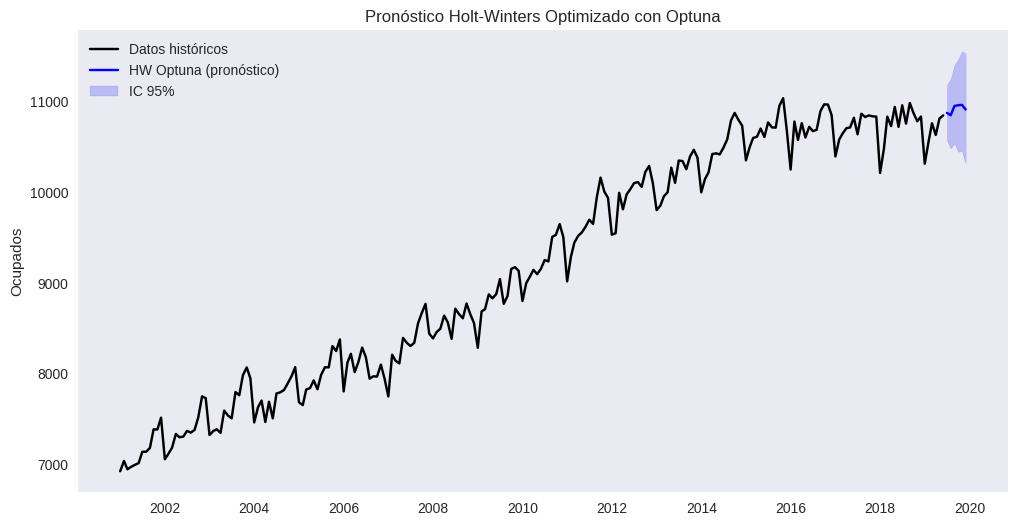

In [97]:
plt.figure(figsize=(12,6))

plt.plot(data["Ocupados"], label="Datos históricos", color="black")
plt.plot(forecast_ci["Pronóstico"], label="HW Optuna (pronóstico)", color="blue")

plt.fill_between(
    forecast_ci.index,
    forecast_ci["Lower_95"],
    forecast_ci["Upper_95"],
    color="blue",
    alpha=0.20,
    label="IC 95%"
)

plt.title("Pronóstico Holt-Winters Optimizado con Optuna")
plt.ylabel("Ocupados")
plt.grid()
plt.legend()
plt.show()


In [105]:
### 5.4.1 Evaluación del Modelo Optuna contra el Test Set (Holdout)

print("\n--- Evaluación Final (Holdout) ---")

# 1. Obtener los mejores parámetros encontrados por Optuna
p_optuna = study_hw.best_params   # usar study_hw, no study_ets

alpha_opt    = p_optuna["alpha"]
beta_opt     = p_optuna["beta"]
gamma_opt    = p_optuna["gamma"]
trend_opt    = p_optuna["trend"]
seasonal_opt = p_optuna["seasonal"]
error_opt    = p_optuna["error"]

print("\nHiperparámetros Optuna seleccionados:")
print(p_optuna)

# 2. Entrenar el modelo SÓLO con datos de ENTRENAMIENTO (train_td)
model_eval_optuna = ETSModel(
    endog=train_td,           # <-- Solo entrenamiento
    trend=trend_opt,
    seasonal=seasonal_opt,
    error=error_opt,
    seasonal_periods=12,
    freq="MS"
)

fit_eval_optuna = model_eval_optuna.fit_constrained({
    "smoothing_level":   alpha_opt,
    "smoothing_trend":   beta_opt,
    "smoothing_seasonal": gamma_opt
})

# 3. Pronóstico EXACTO para la longitud del test_td
forecast_eval_optuna = fit_eval_optuna.forecast(len(test_td))

# Alinear índice con el test_td (evita RMSE incorrectos)
forecast_eval_optuna.index = test_td.index

# 4. Calcular el RMSE contra el periodo de prueba real
rmse_optuna_test = np.sqrt(mean_squared_error(test_td, forecast_eval_optuna))

# 5. Imprimir la comparación final
print(f"\nRMSE Mejor Modelo (Sección 4): {rmse_hw_mul:.4f}")
print(f"RMSE Modelo Optuna (Sección 5): {rmse_optuna_test:.4f}")

if rmse_optuna_test < rmse_hw_mul:
    print("\n✔ ¡El modelo optimizado con Optuna es MEJOR en el holdout!")
else:
    print("\nℹ El modelo de la Sección 4 fue ligeramente mejor en el holdout.")



--- Evaluación Final (Holdout) ---

Hiperparámetros Optuna seleccionados:
{'alpha': 0.5979289966840028, 'beta': 0.04231634915156046, 'gamma': 0.26322575190668174, 'trend': 'mul', 'seasonal': 'mul', 'error': 'mul'}

RMSE Mejor Modelo (Sección 4): 59.4239
RMSE Modelo Optuna (Sección 5): 60.7868

ℹ El modelo de la Sección 4 fue ligeramente mejor en el holdout.
